<a href="https://colab.research.google.com/github/aurabinda90-dev/CFD-in-Python/blob/main/Step_2_Nonlinear_Convection_and_Upwind_Scheme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 2: Nonlinear Convection and Upwind Scheme

In [ ]:
import numpy as np               # we're importing numpy
import matplotlib.pyplot as plt # and our 2D plotting library

%matplotlib inline


nx = 141
dx = 2 / (nx - 1)
nt = 20    #nt is the number of timesteps we want to calculate
#dt = .025  #dt is the amount of time each timestep covers (delta t)

u = np.ones(nx)                         #as before, we initialize u with every value equal to 1.
u[:]= 1
u[int(.5 / dx) : int(1 / dx + 1)] = 2  #then set u = 2 between 0.5 and 1 as per our I.C.s

CFL = 0.9
dt = CFL * dx / max(abs(u))

un = np.ones(nx) #initialize our placeholder array un, to hold the time-stepped solution

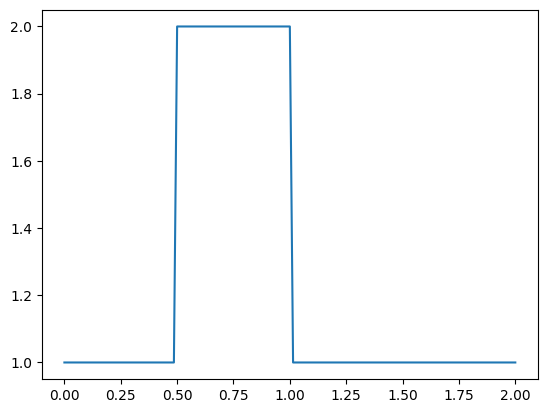

In [ ]:
plt.plot(np.linspace(0, 2, nx), u);
plt.show()

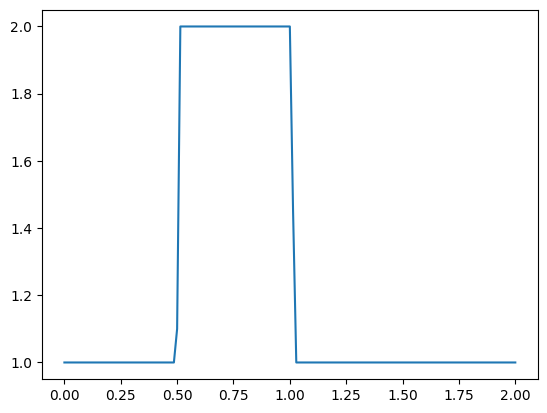

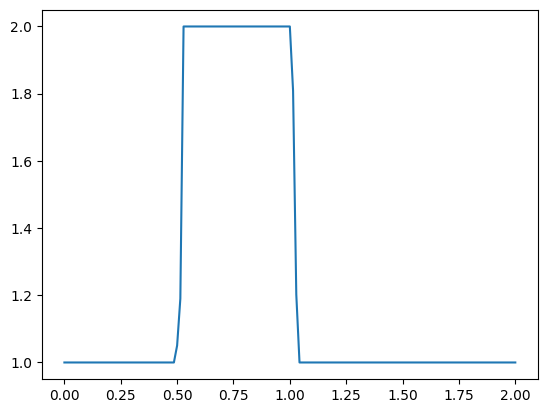

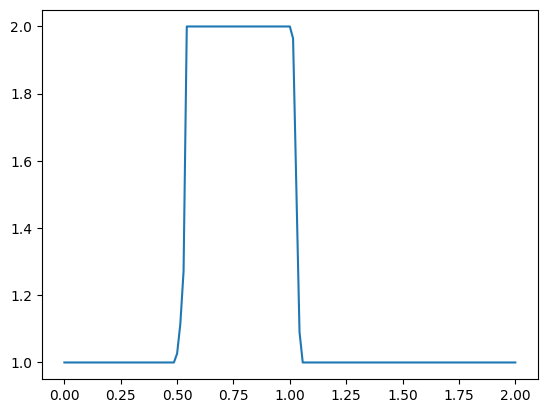

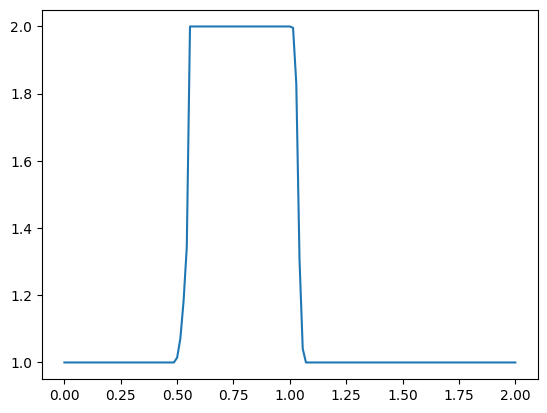

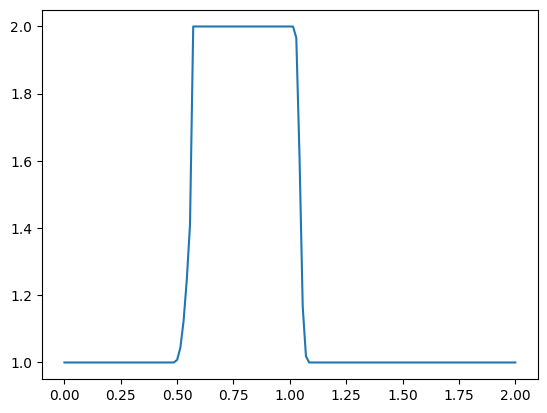

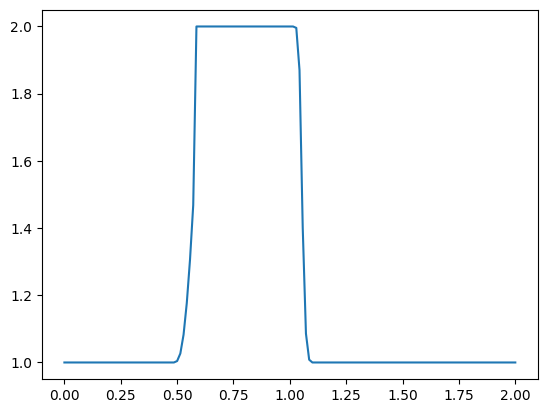

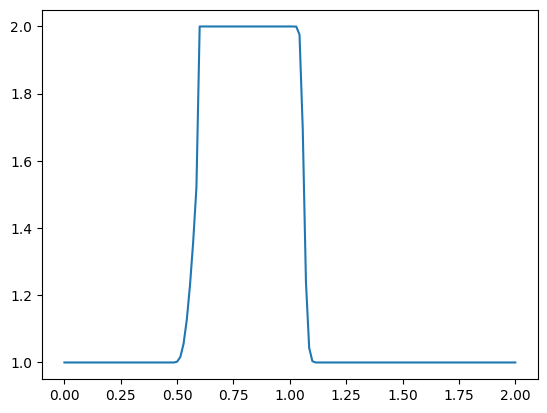

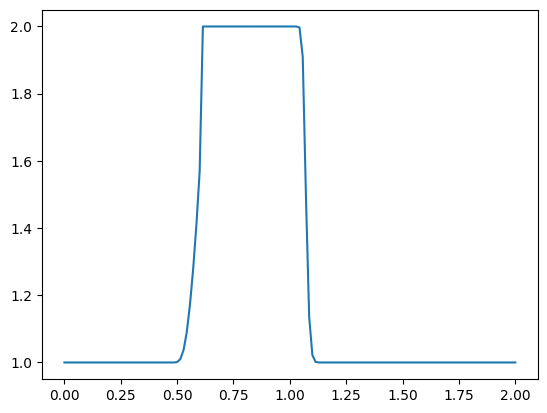

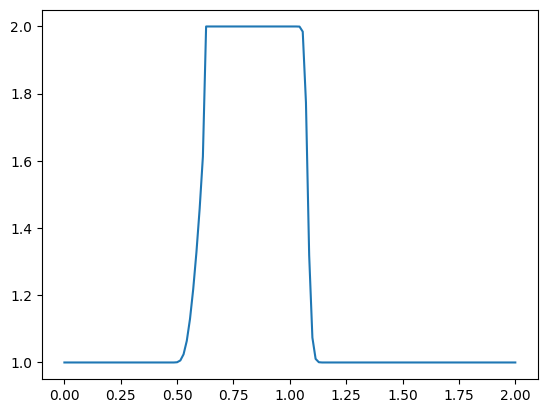

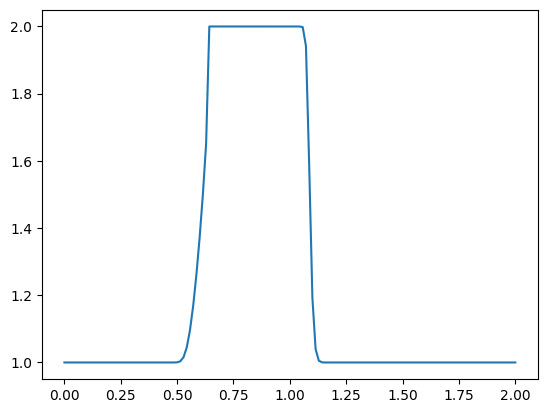

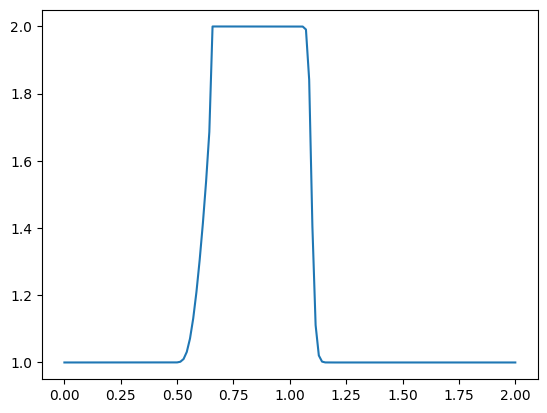

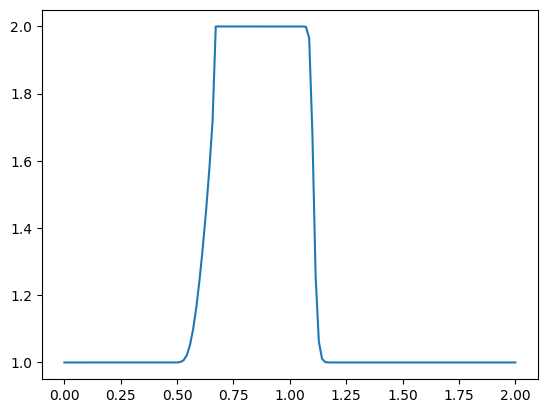

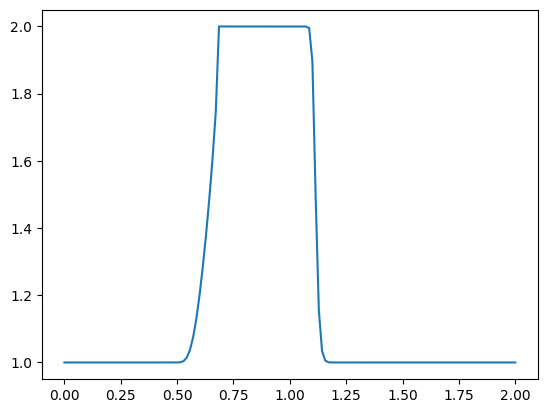

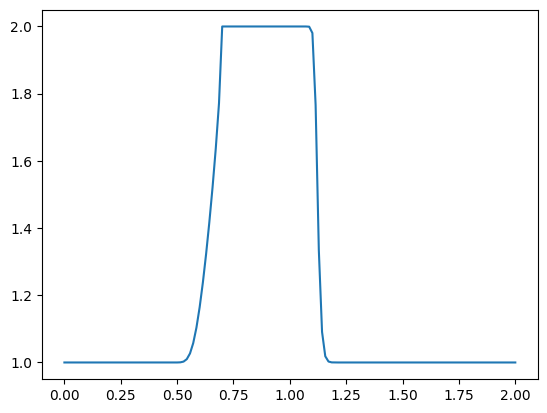

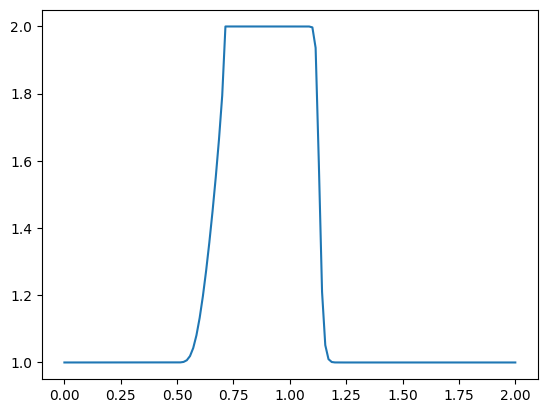

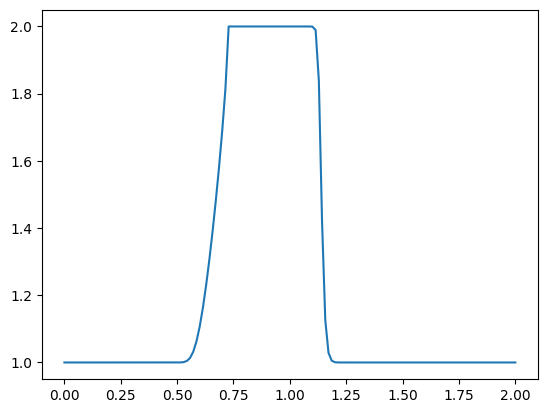

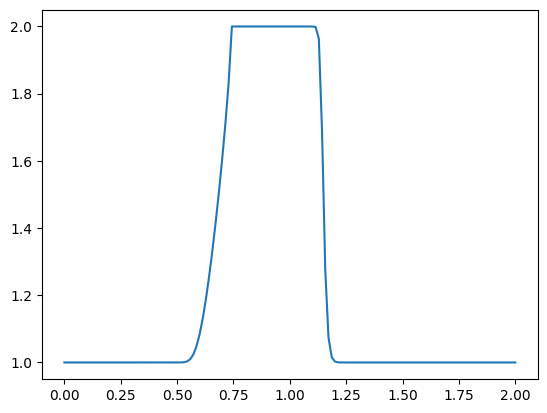

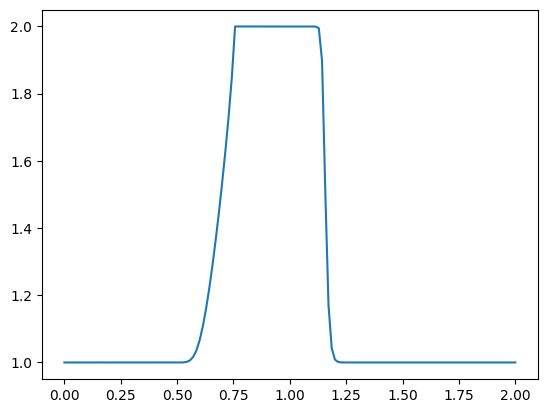

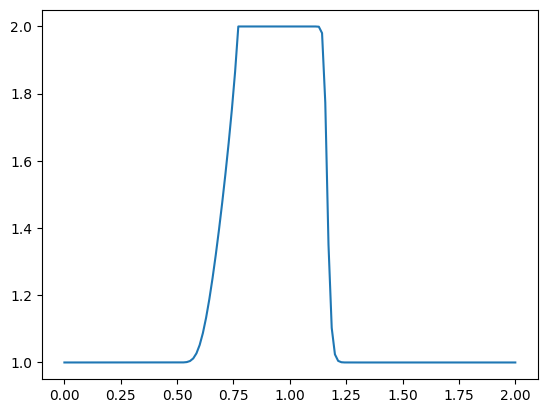

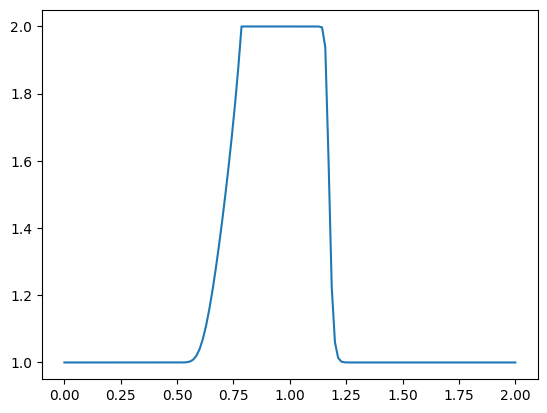

In [ ]:
for n in range(nt):  #iterate through time
    un = u.copy() ##copy the existing values of u into un


    for i in range(1, nx-1):  ##now we'll iterate through the u array
        u[i] = un[i] - un[i] * dt / dx * (un[i] - un[i-1])
    plt.plot(np.linspace(0, 2, nx), u) ##Plot the results
    plt.show()

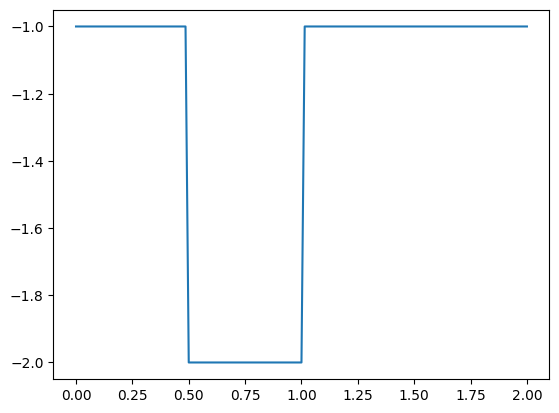

In [ ]:
u[:]= -1
u[int(.5 / dx) : int(1 / dx + 1)] = -2  #then set u = 2 between 0.5 and 1 as per our I.C.s

plt.plot(np.linspace(0, 2, nx), u);
plt.show()

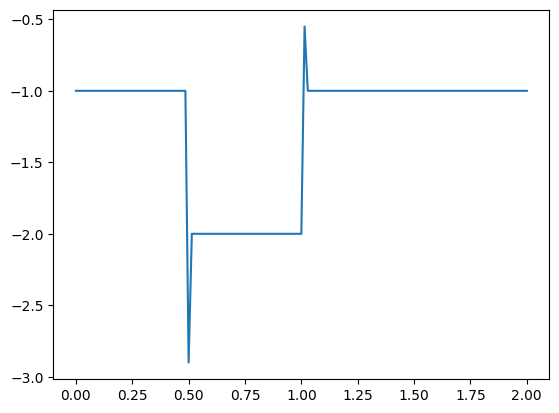

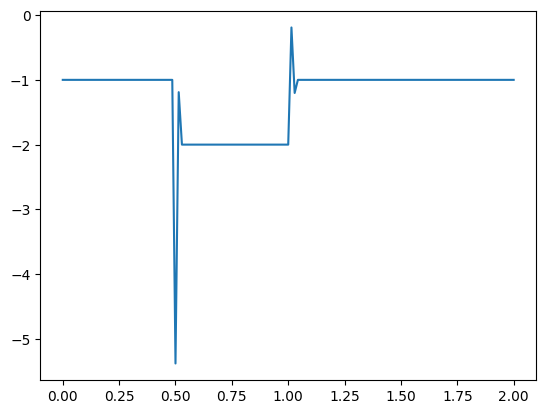

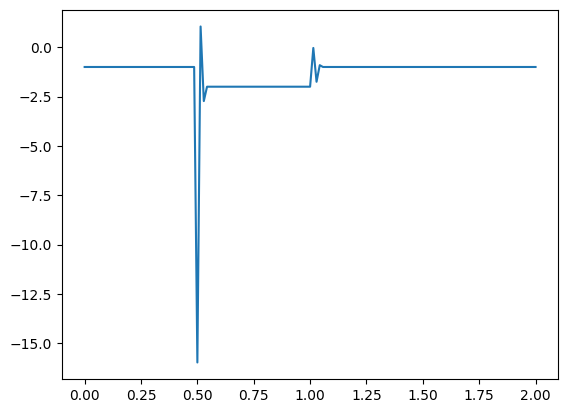

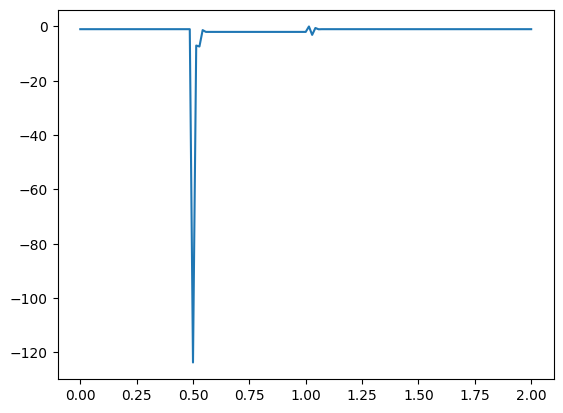

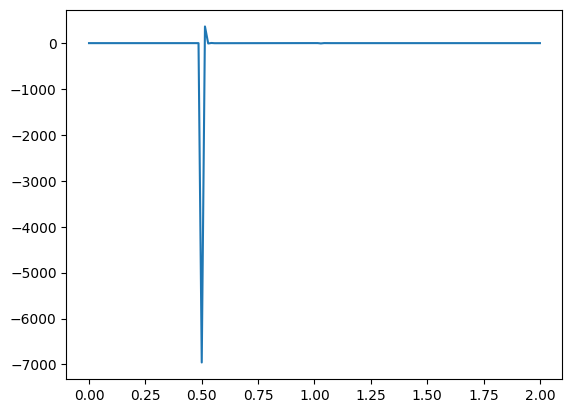

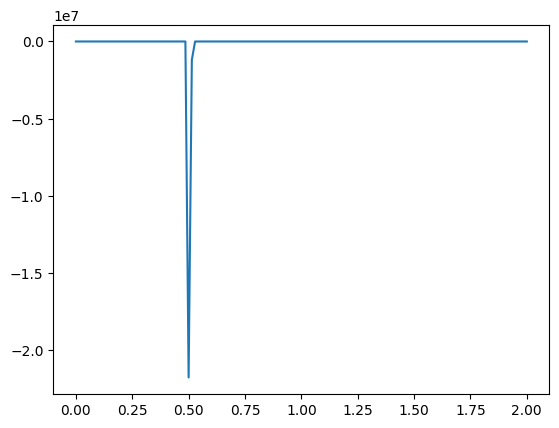

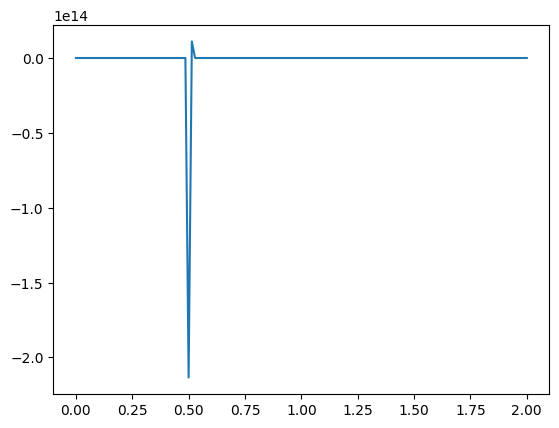

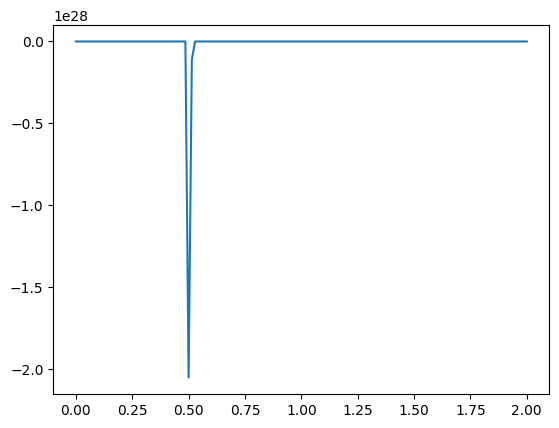

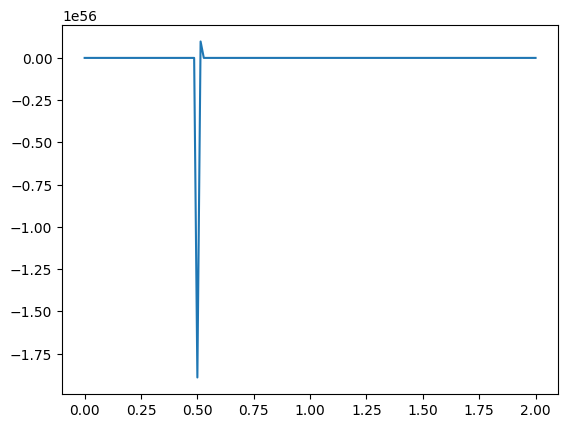

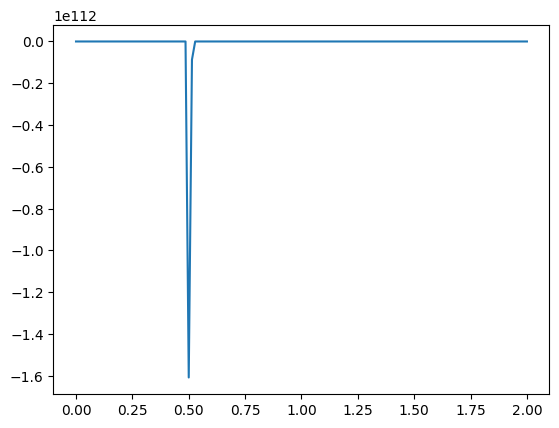

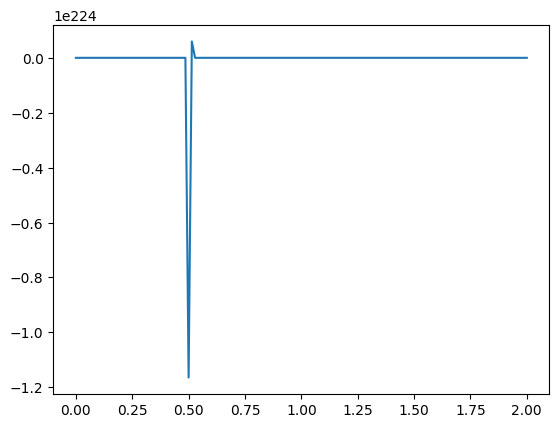

/tmp/ipykernel_5141/2793021359.py:6: RuntimeWarning: overflow encountered in scalar multiply
  u[i] = un[i] - un[i] * dt / dx * (un[i] - un[i-1])


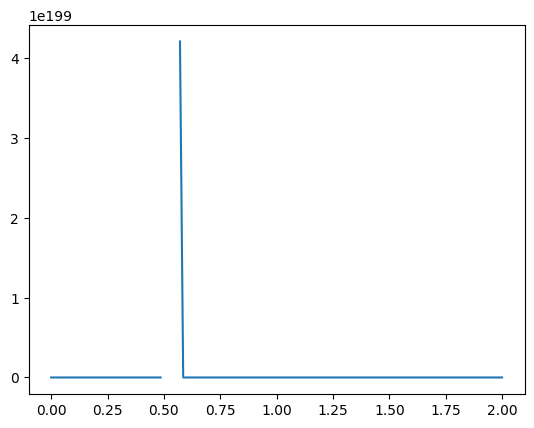

/tmp/ipykernel_5141/2793021359.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  u[i] = un[i] - un[i] * dt / dx * (un[i] - un[i-1])


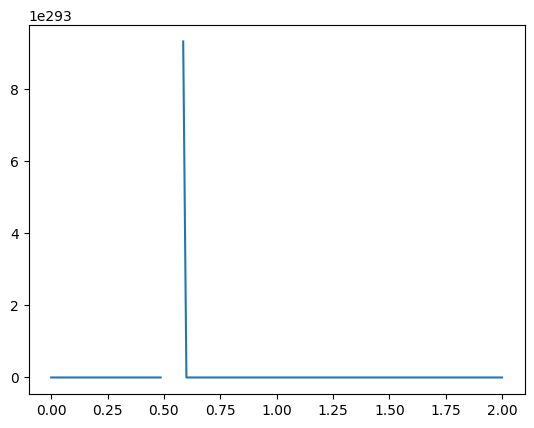

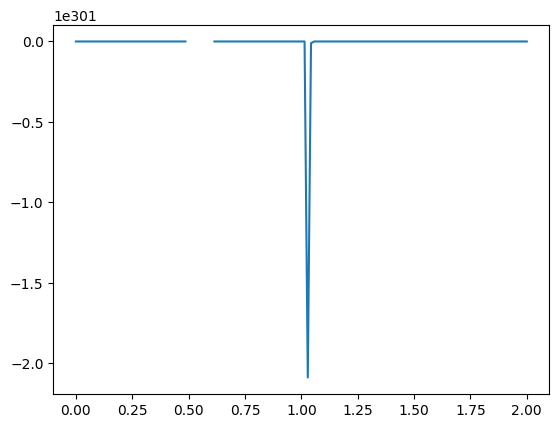

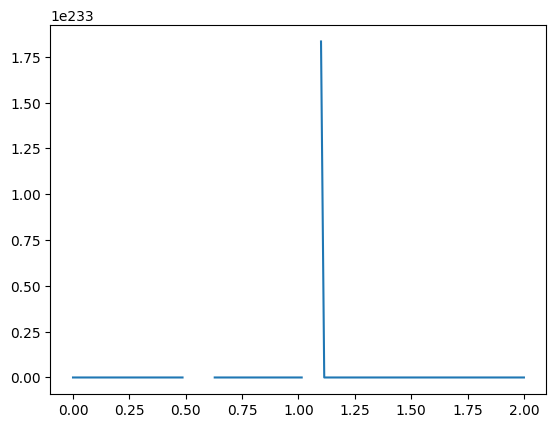

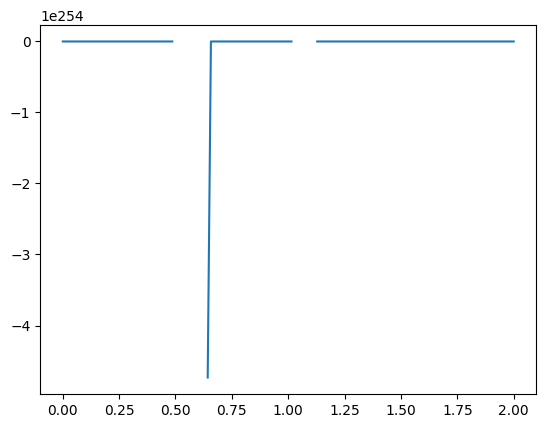

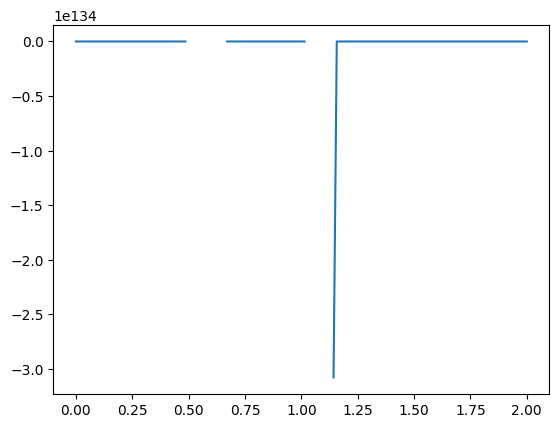

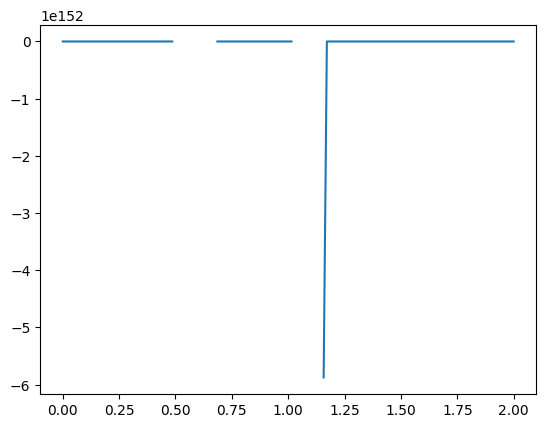

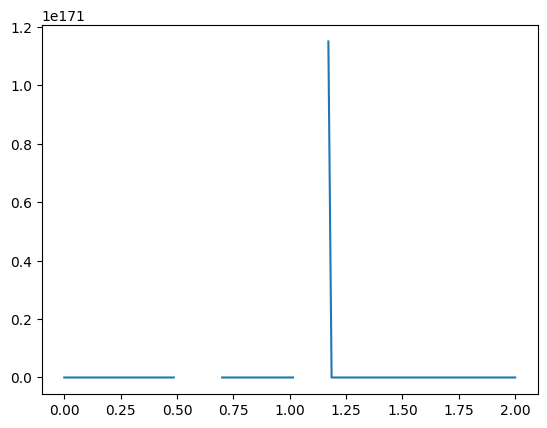

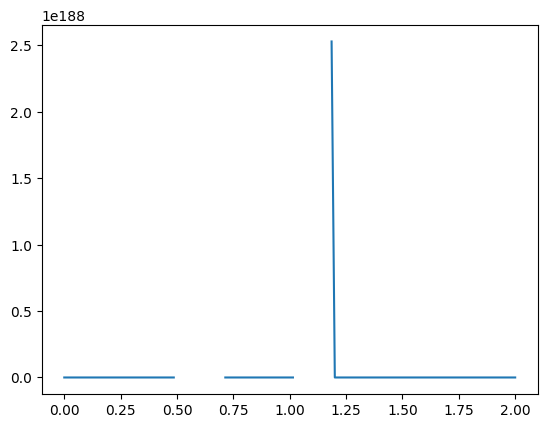

In [ ]:
for n in range(nt):  #iterate through time
    un = u.copy() ##copy the existing values of u into un


    for i in range(1, nx-1):  ##now we'll iterate through the u array
        u[i] = un[i] - un[i] * dt / dx * (un[i] - un[i-1])
    plt.plot(np.linspace(0, 2, nx), u) ##Plot the results
    plt.show()

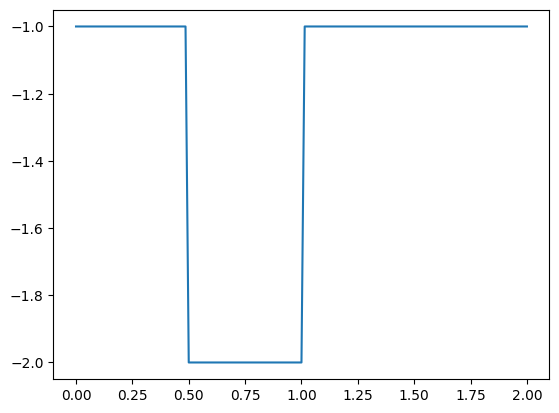

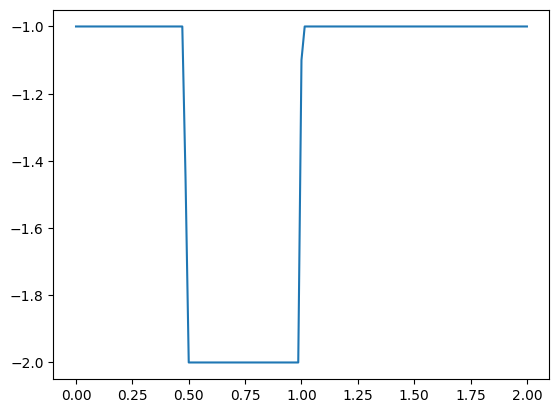

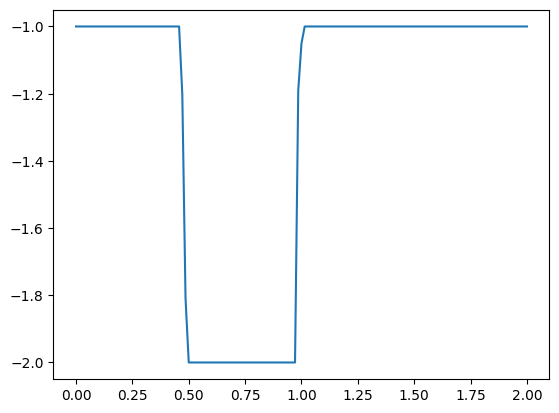

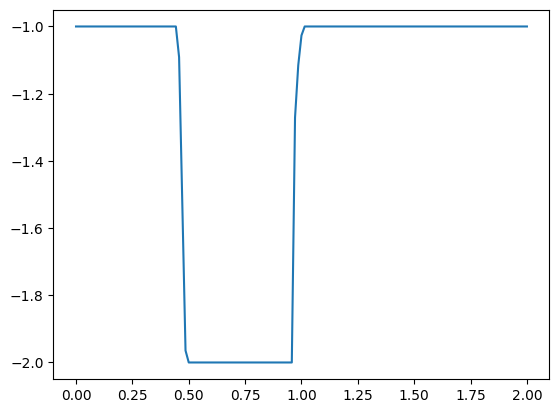

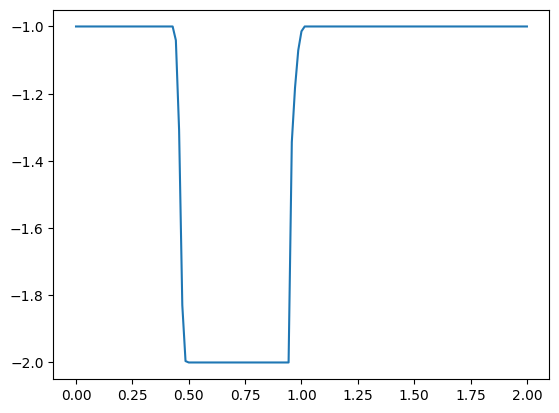

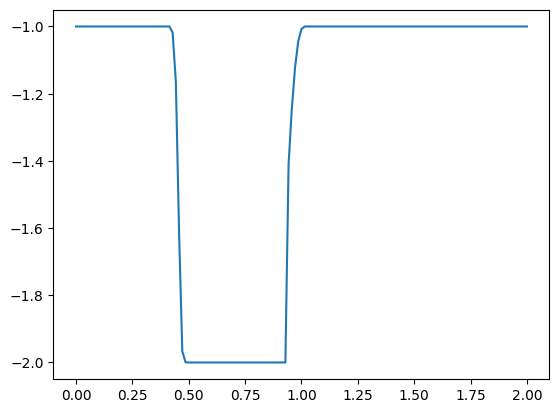

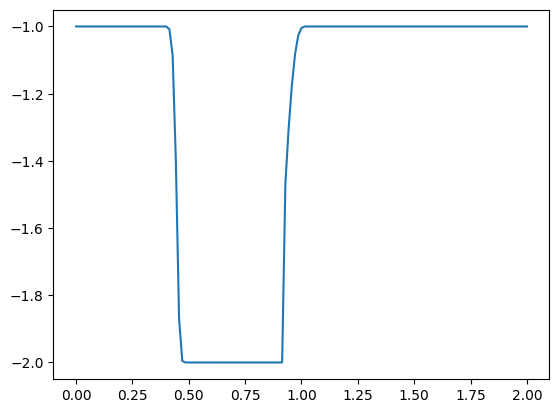

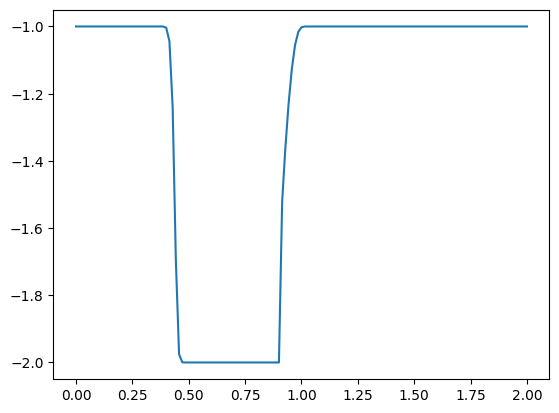

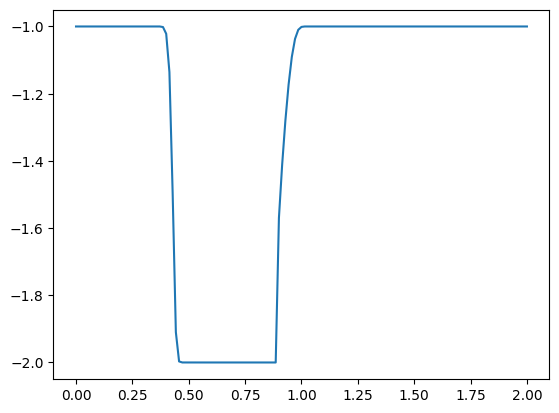

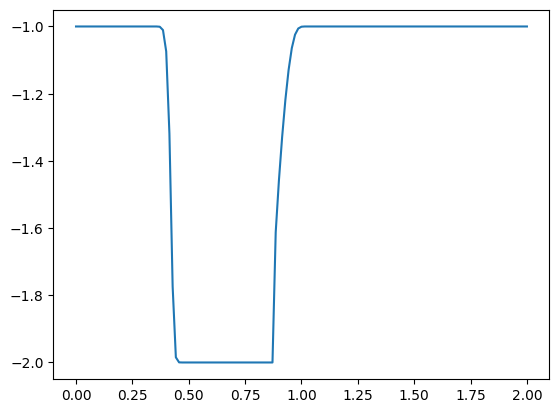

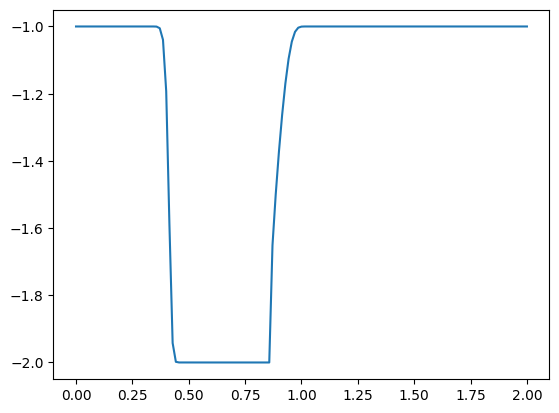

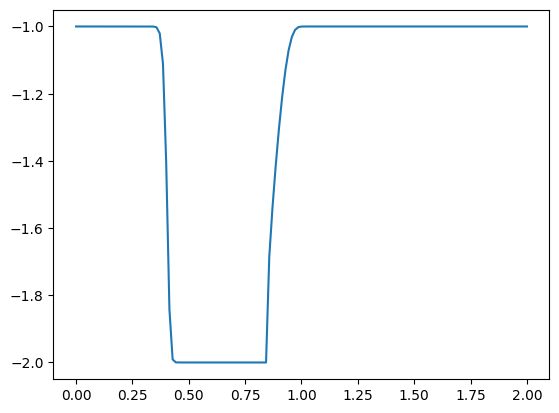

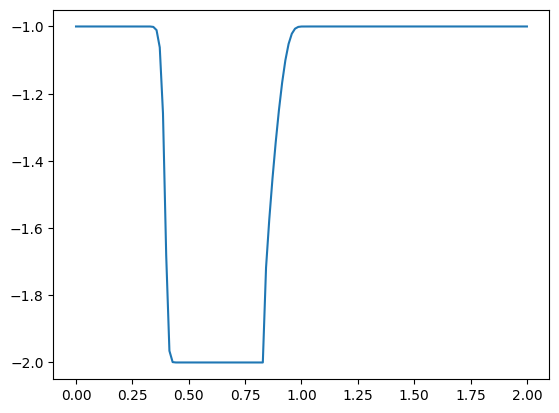

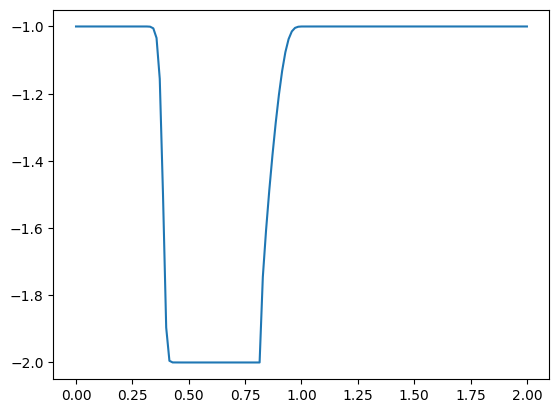

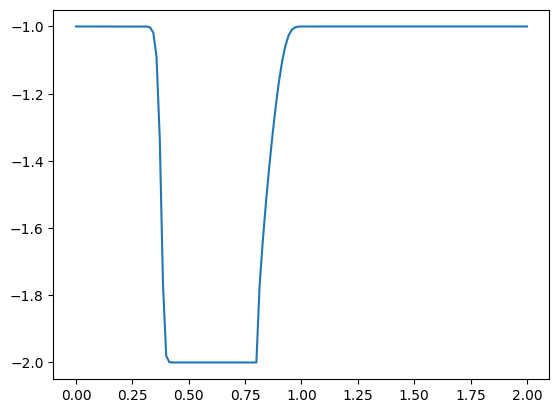

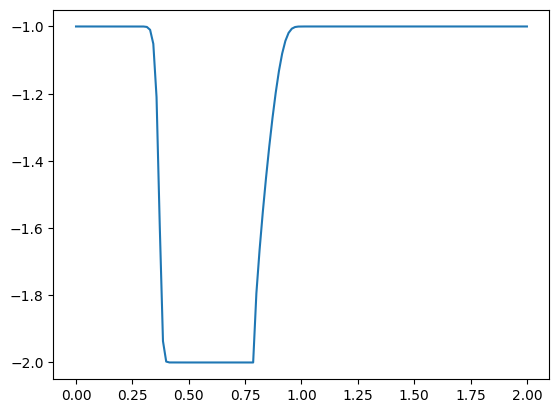

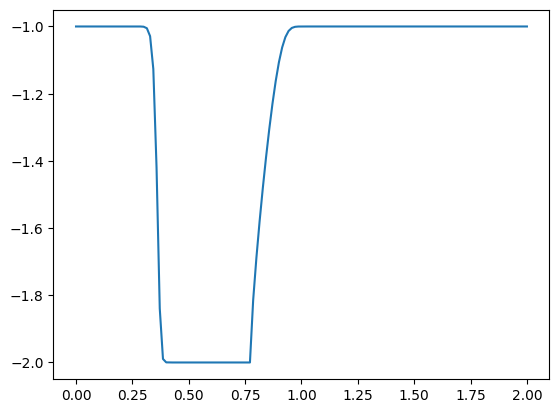

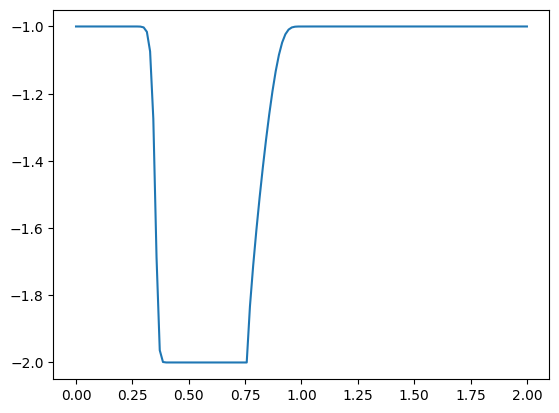

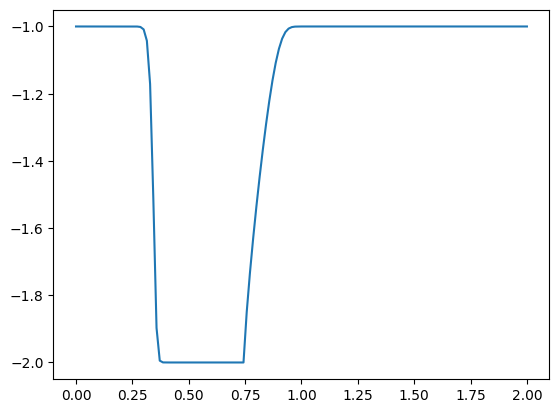

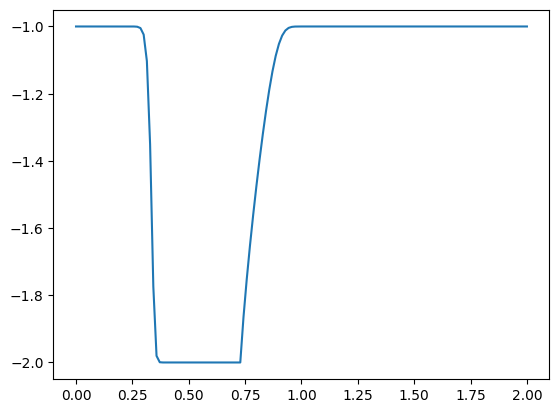

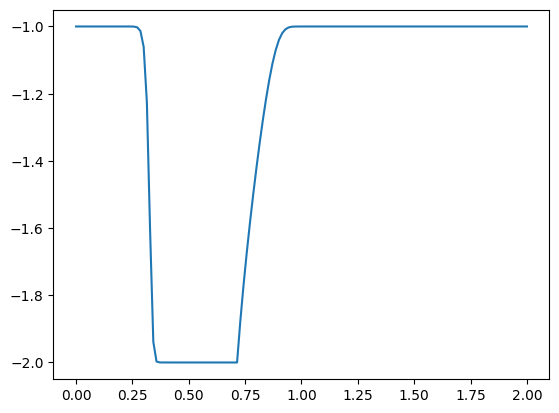

In [ ]:
u[:]= -1
u[int(.5 / dx) : int(1 / dx + 1)] = -2  #then set u = 2 between 0.5 and 1 as per our I.C.s

plt.plot(np.linspace(0, 2, nx), u);
plt.show()

for n in range(nt):  #iterate through time
    un = u.copy() ##copy the existing values of u into un

    F = lambda c: (max(c/(abs(c)+1e-6), 0), max(-c/(abs(c)+1e-6), 0))

    for i in range(1, nx-1):  ##now we'll iterate through the u array
        # Coefficients to the east side of the node (i+1)
        fe1, fe2 = F(u[i])
        # Coefficients to the west side of the node (i-1)
        fw1, fw2 = F(u[i])
        # Differential values on the east side interface
        ue = un[i] * fe1 + un[i+1] * fe2
        # Differential values on the wast side interface
        uw = un[i-1] * fw1 + un[i]* fw2
        u[i] = un[i] - un[i] * dt / dx * (ue - uw)

        #u[i] = un[i] - un[i] * dt / dx * (un[i] - un[i-1])
    plt.plot(np.linspace(0, 2, nx), u) ##Plot the results
    plt.show()